# NER Notebook 2: Training & Evaluation

**BSAN 6200 — Text Mining & Social Media Analytics**

## What You'll Learn
1. **CRF training** — the classic ML approach to sequence labeling
2. **Bi-LSTM training** — neural network approach
3. **Transformer fine-tuning** — modern state-of-the-art with DistilBERT
4. **Entity-level evaluation** with seqeval (the right way to measure NER)
5. **Error analysis** — categorize and diagnose model failures

## Prerequisites
- Notebook 1 (NER inference and data formats)
- Basic understanding of train/test splits and classification metrics

---

In [1]:
# ============================================================
# SETUP: Install all required packages
# ============================================================
# sklearn-crfsuite: CRF implementation for sequence labeling
# seqeval: entity-level evaluation metrics (the correct way to evaluate NER)
# transformers: HuggingFace library for Transformer models
# datasets: HuggingFace datasets library for loading NER benchmarks

#!pip install sklearn-crfsuite seqeval transformers datasets accelerate tensorflow

In [2]:
import sklearn_crfsuite
from sklearn_crfsuite import metrics as crf_metrics
from sklearn.model_selection import train_test_split
from seqeval.metrics import classification_report as seq_report
from seqeval.metrics import f1_score as seq_f1
from seqeval.scheme import IOB2
from sklearn.metrics import classification_report as sklearn_report
import pandas as pd
import numpy as np
import json

print("All packages imported!")

All packages imported!


---
## Part 1: Conditional Random Fields (CRF)

CRF is a probabilistic model for **sequence labeling**. Think of it as a
"smart proofreader" that looks at neighboring tokens to ensure label
sequences are consistent.

**How CRF works for NER:**
1. Extract features for each token (is it capitalized? what's the previous word?)
2. Learn transition patterns from training data (e.g., B-PER is often followed by I-PER)
3. At prediction time, find the most likely label sequence considering both features AND transitions

**Pros:** Fast, interpretable, works with small data
**Cons:** Requires hand-crafted features, can't handle unseen words well

In [3]:
# ============================================================
# LOAD TRAINING DATA: CoNLL format
# ============================================================
# We'll use the WNUT17 dataset (Emerging entities from social media)
# This dataset has entities that are harder to detect: new companies,
# creative works, products, etc.

def read_conll(filename):
    """
    Read a CoNLL-formatted file into a list of sentences.

    Each sentence is a list of (token, label) tuples.
    Sentences are separated by blank lines in the file.

    Returns:
        List[List[Tuple[str, str]]]: list of sentences,
        where each sentence is a list of (token, tag) pairs
    """
    sentences = []
    with open(filename, encoding="utf-8") as f:
        sentence = []
        for line in f:
            line = line.strip()
            if line:
                # Each non-empty line has: token<tab>label
                parts = line.split("\t")
                if len(parts) >= 2:
                    sentence.append((parts[0], parts[1]))
            else:
                # Blank line = end of sentence
                if sentence:
                    sentences.append(sentence)
                    sentence = []
        # Don't forget the last sentence (if file doesn't end with blank line)
        if sentence:
            sentences.append(sentence)
    return sentences

# Download WNUT17 data
import urllib.request
import os

wnut_url = "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/wnut17train.conll"
if not os.path.exists("wnut17train.conll"):
    urllib.request.urlretrieve(wnut_url, "wnut17train.conll")
    print("Downloaded WNUT17 training data")

sentences = read_conll("wnut17train.conll")
print(f"Loaded {len(sentences)} sentences")
print(f"\nExample sentence:")
for token, tag in sentences[0]:
    marker = "  ←" if tag != "O" else ""
    print(f"  {token:<20} {tag}{marker}")

Loaded 3394 sentences

Example sentence:
  @paulwalk            O
  It                   O
  's                   O
  the                  O
  view                 O
  from                 O
  where                O
  I                    O
  'm                   O
  living               O
  for                  O
  two                  O
  weeks                O
  .                    O
  Empire               B-location  ←
  State                I-location  ←
  Building             I-location  ←
  =                    O
  ESB                  B-location  ←
  .                    O
  Pretty               O
  bad                  O
  storm                O
  here                 O
  last                 O
  evening              O
  .                    O


In [ ]:
# ============================================================
# FEATURE ENGINEERING: Define what the CRF sees for each token
# ============================================================
# CRF is NOT a neural network — it cannot read raw text.
# You must manually define a "feature dictionary" for every token.
# Think of it as filling out a form for each word in the sentence.
#
# The CRF then learns weights for each feature during training.
# For example, it might learn:
#   "If word.istitle() is True AND next word is also title case,
#    this token is probably B-PERSON"
#
# We define three groups of features:
#   1. Current word features — "What does this word look like?"
#   2. Previous word features — "What came before?" (left context)
#   3. Next word features — "What comes after?" (right context)
#
# This gives the CRF a window of 3 tokens (prev, current, next)
# but only through these hand-picked features. It never sees raw text.
# This is the key limitation vs Bi-LSTM (learns its own features)
# and Transformers (sees full sentence with pretrained knowledge).

def word2features(sent, i):
    """
    Extract features for the i-th token in a sentence.

    Features capture:
    1. Properties of the current word (shape, suffix, case)
    2. Properties of the previous word (context from the left)
    3. Properties of the next word (context from the right)
    4. Position markers (beginning/end of sentence)

    Args:
        sent: list of (token, tag) tuples
        i: index of the current token

    Returns:
        dict: feature name → feature value
    """
    word = sent[i][0]

    # ==========================================================
    # GROUP 1: Current word features — "What does this word look like?"
    # ==========================================================
    # Each feature captures a different signal about the word.
    # The CRF learns which combinations predict which entity tags.

    features = {
        # bias: always 1.0 — a constant baseline feature.
        # Lets the CRF learn a default tendency for each tag
        # (e.g., most tokens are "O", so the bias weight for "O" will be high)
        'bias': 1.0,

        # word.lower(): the word itself, lowercased.
        # Lets the CRF memorize specific words seen in training.
        # Example: "google" → likely ORG, "january" → likely DATE
        'word.lower()': word.lower(),

        # word[-3:] and word[-2:]: suffix features (last 2-3 characters).
        # Suffixes reveal word type without memorizing the whole word.
        # Examples: "-tion" = probably not entity, "-berg" = maybe PERSON,
        #           "-Inc" = maybe ORG, "-day" = maybe DATE
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],

        # word.isupper(): is the word ALL CAPS?
        # ALL CAPS words are often acronyms = likely ORG or PRODUCT
        # Examples: NASA, FBI, GDP, NYSE, EBITDA
        'word.isupper()': word.isupper(),

        # word.istitle(): is the word Title Case (first letter capitalized)?
        # Title case is the strongest single signal for named entities.
        # Examples: "Thomas", "Google", "California", "January"
        # Non-entities are rarely title case mid-sentence.
        'word.istitle()': word.istitle(),

        # word.isdigit(): is the word a pure number?
        # Pure numbers appear in DATE ("2024"), MONEY ("500"), PERCENT ("15")
        # Examples: "2024" → DATE, "500" in "$500" → MONEY
        'word.isdigit()': word.isdigit(),

        # word.isalpha(): does the word contain ONLY letters?
        # False for "U.S.", "3rd", "$500", "Manuel-Miranda"
        # Helps distinguish clean words from mixed alphanumeric tokens
        'word.isalpha()': word.isalpha(),

        # word.length: character count of the word.
        # Very short words (1-2 chars) are rarely entities.
        # Very long words might be organization names or compounds.
        'word.length': len(word),

        # word.has_hyphen: does the word contain a hyphen?
        # Hyphenated words are often multi-part names: "Manuel-Miranda",
        # "Hewlett-Packard", or compound modifiers
        'word.has_hyphen': '-' in word,

        # word.has_dollar: does the word contain a dollar sign?
        # Strong signal for MONEY entities: "$500", "$81.8"
        'word.has_dollar': '$' in word,

        # word.has_at: does the word contain an @ sign?
        # Social media handles in the WNUT17 dataset: "@elonmusk"
        'word.has_at': '@' in word,
    }

    # ==========================================================
    # GROUP 2: Previous word features — "What came before?"
    # ==========================================================
    # Left context helps resolve ambiguity.
    # Examples:
    #   "Dr." before "Chen"       → PERSON (title signals a name follows)
    #   "in" before "California"  → LOC (preposition signals a location follows)
    #   "at" before "Google"      → ORG (preposition signals an org follows)
    #   "$" before "500"          → MONEY (currency symbol signals amount)
    #
    # If this is the FIRST token (i=0), there's no previous word,
    # so we set BOS=True (Beginning Of Sentence) instead.
    # BOS helps because sentence-initial words are often entities
    # in news/social media text (e.g., "Apple announced...")

    if i > 0:
        word1 = sent[i-1][0]
        features.update({
            '-1:word.lower()': word1.lower(),       # what word came before
            '-1:word.istitle()': word1.istitle(),   # was it title case (another name?)
            '-1:word.isupper()': word1.isupper(),   # was it all caps (acronym?)
        })
    else:
        features['BOS'] = True  # Beginning Of Sentence — no left context

    # ==========================================================
    # GROUP 3: Next word features — "What comes after?"
    # ==========================================================
    # Right context also resolves ambiguity.
    # Examples:
    #   "Apple" followed by "announced" → ORG (verb = company doing something)
    #   "Apple" followed by "pie"       → NOT an entity (food context)
    #   "Tim" followed by "Cook"        → B-PERSON (another name follows)
    #   "January" followed by "2025"    → DATE (year follows month)
    #
    # If this is the LAST token, there's no next word,
    # so we set EOS=True (End Of Sentence) instead.

    if i < len(sent) - 1:
        word1 = sent[i+1][0]
        features.update({
            '+1:word.lower()': word1.lower(),       # what word comes next
            '+1:word.istitle()': word1.istitle(),   # is it title case (continuation?)
            '+1:word.isupper()': word1.isupper(),   # is it all caps
        })
    else:
        features['EOS'] = True  # End Of Sentence — no right context

    return features

# ==========================================================
# HELPER FUNCTIONS: Convert full sentences
# ==========================================================
# These apply word2features to every token in a sentence

def sent2features(sent):
    """Extract features for all tokens in a sentence."""
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    """Extract labels for all tokens in a sentence."""
    return [label for token, label in sent]

def sent2tokens(sent):
    """Extract tokens for all tokens in a sentence."""
    return [token for token, label in sent]

# ==========================================================
# EXAMPLE: See what features look like for a real token
# ==========================================================
# This shows the actual feature dict the CRF receives for "Thomas"
# (first token in the first sentence of WNUT17)

print("Features for 'Thomas' (first token):")
features = word2features(sentences[0], 0)
for name, value in list(features.items()):
    print(f"  {name:<25} = {value}")
print(f"\nTotal features: {len(features)}")

# ==========================================================
# NOTE: You could add MORE features to improve CRF performance:
#   - POS tags (noun, verb, etc.) from spaCy or NLTK
#   - Word embeddings (dense vector features)
#   - Character n-grams (all 3-char substrings)
#   - Gazetteers (is this word in a known list of cities/companies?)
#   - Wider context window (-2, +2 tokens)
#
# But more features = more engineering effort, which is exactly
# why the field moved to neural models (Bi-LSTM, Transformers)
# that learn their own features automatically.
# ==========================================================

Features for 'Thomas' (first token):
  bias                      = 1.0
  word.lower()              = @paulwalk
  word[-3:]                 = alk
  word[-2:]                 = lk
  word.isupper()            = False
  word.istitle()            = False
  word.isdigit()            = False
  word.isalpha()            = False
  word.length               = 9
  word.has_hyphen           = False
  ... (16 features total)


In [5]:
# ============================================================
# TRAIN/TEST SPLIT AND CRF TRAINING
# ============================================================

# Split data: 80% train, 20% test
train_sents, test_sents = train_test_split(
    sentences, test_size=0.2, random_state=42
)
print(f"Train: {len(train_sents)} sentences")
print(f"Test:  {len(test_sents)} sentences")

# Extract features and labels
X_train = [sent2features(s) for s in train_sents]
y_train = [sent2labels(s) for s in train_sents]
X_test = [sent2features(s) for s in test_sents]
y_test = [sent2labels(s) for s in test_sents]

# Train the CRF model
# c1 and c2 are regularization parameters (prevent overfitting)
# algorithm='lbfgs' is a standard optimization method
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,               # L1 regularization
    c2=0.1,               # L2 regularization
    max_iterations=100,    # training iterations
    all_possible_transitions=True,  # consider all label transitions
)

print("Training CRF model...")
crf.fit(X_train, y_train)
print("Training complete!")

Train: 2715 sentences
Test:  679 sentences
Training CRF model...
Training complete!


---
## Part 2: NER Evaluation — The Right Way

### Why Token-Level Accuracy is WRONG for NER

Most tokens are "O" (not entities). A model that predicts "O" for everything
would get ~90% accuracy! This is why we need **entity-level** evaluation.

### Entity-Level Evaluation with seqeval

seqeval evaluates whether the **complete entity span** was correctly predicted:
- "Thomas Jefferson" as PERSON → correct only if BOTH tokens are labeled correctly
- "Thomas" alone → WRONG (partial match = miss in strict mode)

**Always use seqeval for NER evaluation. Never use sklearn accuracy.**

In [6]:
# ============================================================
# WRONG WAY: Token-level evaluation (DO NOT USE for NER!)
# ============================================================
# This inflates scores because most tokens are "O"

y_pred = crf.predict(X_test)

# Flatten to individual tokens for sklearn
y_true_flat = [tag for sent in y_test for tag in sent]
y_pred_flat = [tag for sent in y_pred for tag in sent]

print("=" * 60)
print("⚠️  TOKEN-LEVEL METRICS (sklearn) — MISLEADING!")
print("=" * 60)

# Count how many tokens are "O"
o_count = y_true_flat.count("O")
total = len(y_true_flat)
print(f"\n{o_count}/{total} tokens ({o_count/total*100:.1f}%) are 'O' — this inflates accuracy!")

# Show the misleading accuracy
accuracy = sum(t == p for t, p in zip(y_true_flat, y_pred_flat)) / len(y_true_flat)
print(f"Token accuracy: {accuracy:.4f} — looks great, but is it?\n")

⚠️  TOKEN-LEVEL METRICS (sklearn) — MISLEADING!

12128/12725 tokens (95.3%) are 'O' — this inflates accuracy!
Token accuracy: 0.9683 — looks great, but is it?



In [7]:
# ============================================================
# RIGHT WAY: Entity-level evaluation with seqeval
# ============================================================
# seqeval evaluates COMPLETE entity spans, not individual tokens

print("=" * 60)
print("✓  ENTITY-LEVEL METRICS (seqeval) — CORRECT for NER")
print("=" * 60)
print(seq_report(y_test, y_pred))

# Also get the overall F1 score
overall_f1 = seq_f1(y_test, y_pred)
print(f"Overall entity-level F1: {overall_f1:.4f}")
print(f"\nNotice: Entity F1 is much lower than token accuracy!")
print("This is the TRUE measure of NER performance.")

✓  ENTITY-LEVEL METRICS (seqeval) — CORRECT for NER
               precision    recall  f1-score   support

  corporation       0.95      0.51      0.67        39
creative-work       0.73      0.27      0.39        30
        group       0.79      0.18      0.29        62
     location       0.79      0.51      0.62       117
       person       0.79      0.36      0.49       136
      product       0.00      0.00      0.00        20

    micro avg       0.80      0.37      0.50       404
    macro avg       0.67      0.31      0.41       404
 weighted avg       0.76      0.37      0.48       404

Overall entity-level F1: 0.5025

Notice: Entity F1 is much lower than token accuracy!
This is the TRUE measure of NER performance.


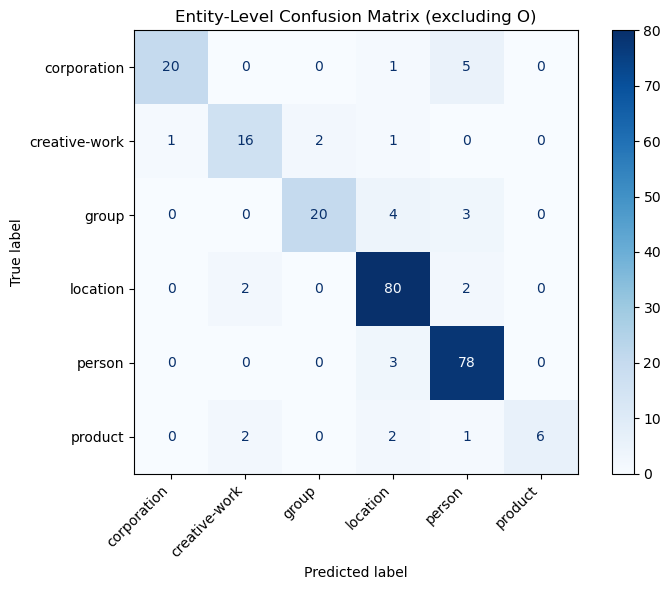

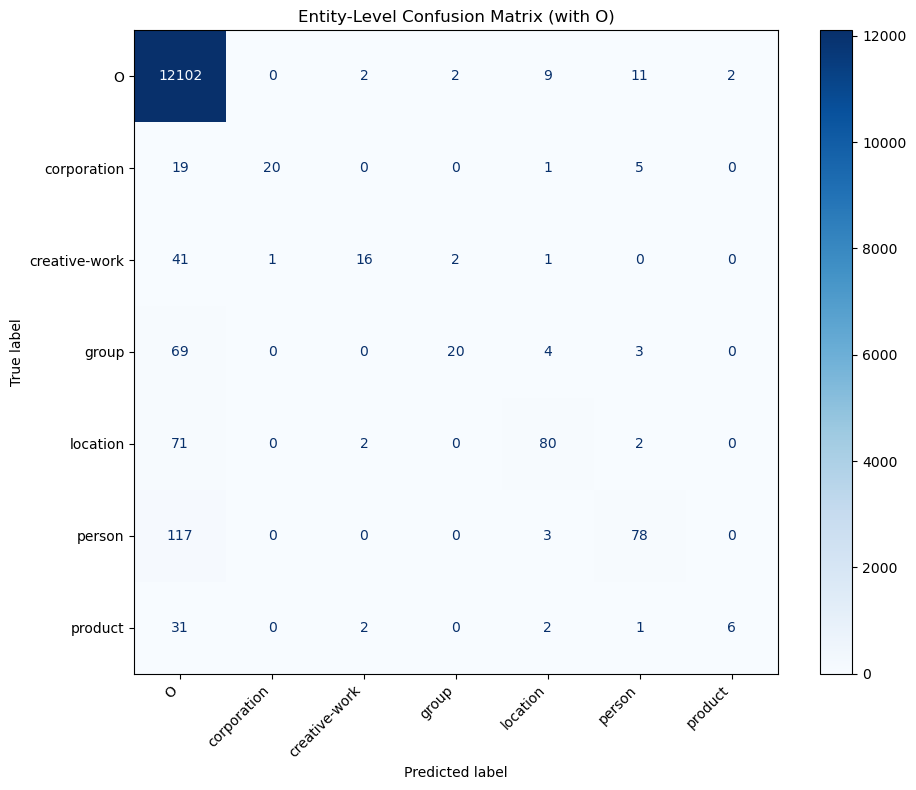

In [29]:
    # ============================================================
    # CONFUSION MATRIX: Entity-level (recommended)
    # ============================================================
    # Collapse B- and I- prefixes to focus on entity TYPE confusion
    # This tells you: is the model confusing PER with ORG? Missing DATE?

    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    def collapse_bio(tag):
        """Remove B-/I- prefix: 'B-PER' → 'PER', 'I-ORG' → 'ORG', 'O' → 'O'."""
        if tag.startswith("B-") or tag.startswith("I-"):
            return tag[2:]
        return tag

    # Flatten all predictions and gold labels
    y_true_flat = [collapse_bio(tag) for sent in y_test for tag in sent]
    y_pred_flat = [collapse_bio(tag) for sent in y_pred for tag in sent]

    # Get entity labels only (exclude "O" to focus on what matters)
    entity_labels = sorted(set(y_true_flat + y_pred_flat) - {"O"})

    # Option A: Entity types only (exclude "O")
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=entity_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=entity_labels)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title("Entity-Level Confusion Matrix (excluding O)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Option B: Include "O" to see false positives/negatives
    all_labels = ["O"] + entity_labels
    fig, ax = plt.subplots(figsize=(10, 8))
    cm_full = confusion_matrix(y_true_flat, y_pred_flat, labels=all_labels)
    disp_full = ConfusionMatrixDisplay(cm_full, display_labels=all_labels)
    disp_full.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title("Entity-Level Confusion Matrix (with O)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [32]:
# ============================================================
# CONFUSION MATRIX: Token-level with B/I tags (advanced)
# ============================================================
# Use this to diagnose BOUNDARY errors:
#   B-PER predicted as I-PER → model found the entity but missed the start
#   I-PER predicted as O     → model cut the entity span short
#   B-PER predicted as B-ORG → entity type confusion at the start

def plot_ner_confusion_matrix(y_true_sents, y_pred_sents, title="", exclude_O=True):
    """
    Plot entity-level confusion matrix from any NER model's output.
    Works with CRF, Bi-LSTM, Bi-LSTM+CRF, or Transformer predictions.
    
    Args:
        y_true_sents: list of list of gold tag strings
        y_pred_sents: list of list of predicted tag strings
        title: plot title
        exclude_O: if True, remove "O" tags for cleaner visualization
    """
    y_true_flat = [collapse_bio(tag) for sent in y_true_sents for tag in sent]
    y_pred_flat = [collapse_bio(tag) for sent in y_pred_sents for tag in sent]
    
    labels = sorted(set(y_true_flat + y_pred_flat))
    if exclude_O:
        labels = [l for l in labels if l != "O"]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(title or "Entity-Level Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

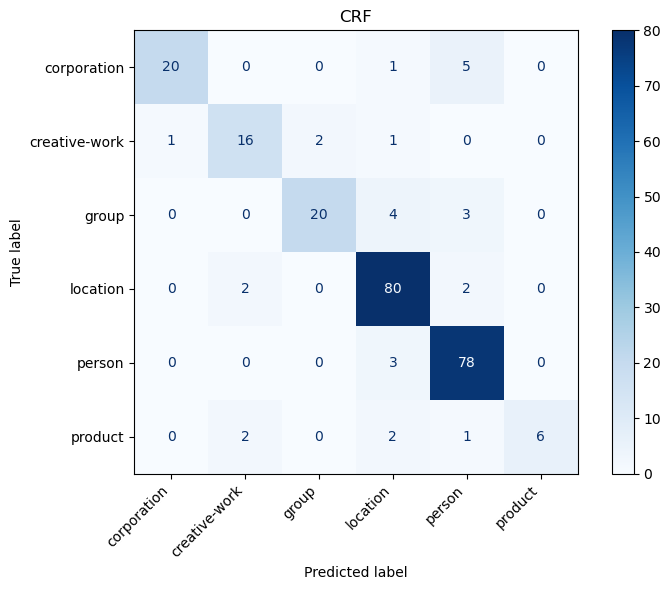

In [33]:
plot_ner_confusion_matrix(y_test, y_pred, "CRF")


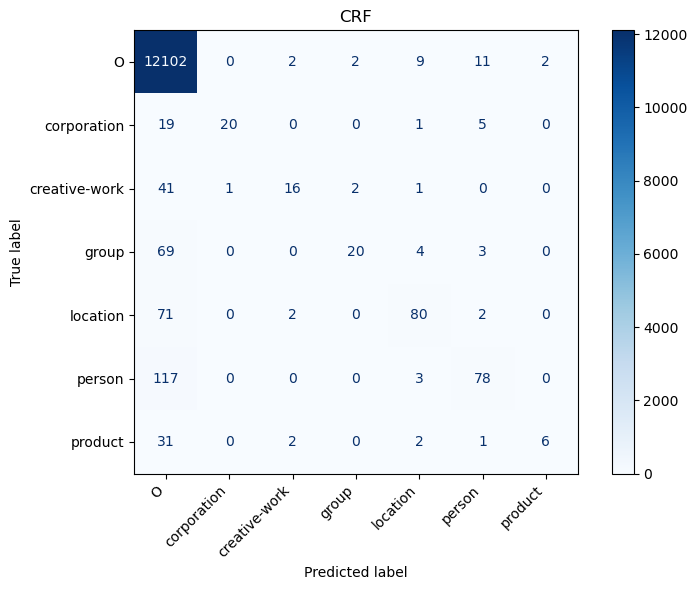

In [34]:
plot_ner_confusion_matrix(y_test, y_pred, "CRF",exclude_O =False)


In [30]:
# ============================================================
# ERROR ANALYSIS: What types of mistakes is the model making?
# ============================================================
# Understanding errors helps you improve the model:
# - Missed entities → need more training examples
# - Spurious entities → need negative examples
# - Type mismatches → need clearer annotation guidelines

def extract_entities(tags, tokens):
    """Extract entities as (text, label) tuples from IOB tags."""
    entities = []
    current_tokens, current_label = [], None

    for token, tag in zip(tokens, tags):
        if tag.startswith("B-"):
            if current_label:
                entities.append((" ".join(current_tokens), current_label))
            current_tokens = [token]
            current_label = tag[2:]
        elif tag.startswith("I-") and current_label:
            current_tokens.append(token)
        else:
            if current_label:
                entities.append((" ".join(current_tokens), current_label))
            current_tokens, current_label = [], None

    if current_label:
        entities.append((" ".join(current_tokens), current_label))
    return set(entities)

# Categorize errors
missed, spurious, type_mismatch = [], [], []

for sent, true_tags, pred_tags in zip(test_sents, y_test, y_pred):
    tokens = sent2tokens(sent)
    true_ents = extract_entities(true_tags, tokens)
    pred_ents = extract_entities(pred_tags, tokens)

    true_texts = {e[0] for e in true_ents}
    pred_texts = {e[0] for e in pred_ents}

    for ent in true_ents - pred_ents:
        if ent[0] in pred_texts:
            pred_label = [p[1] for p in pred_ents if p[0] == ent[0]][0]
            type_mismatch.append({"entity": ent[0], "true": ent[1], "pred": pred_label})
        else:
            missed.append({"entity": ent[0], "label": ent[1]})

    for ent in pred_ents - true_ents:
        if ent[0] not in true_texts:
            spurious.append({"entity": ent[0], "label": ent[1]})

print("ERROR ANALYSIS")
print("=" * 60)
print(f"\nMISSED entities (False Negatives): {len(missed)}")
for ex in missed[:30]:
    print(f"  • \"{ex['entity']}\" ({ex['label']})")

print(f"\nSPURIOUS entities (False Positives): {len(spurious)}")
for ex in spurious[:5]:
    print(f"  • \"{ex['entity']}\" ({ex['label']})")

print(f"\nTYPE MISMATCHES (wrong label): {len(type_mismatch)}")
for ex in type_mismatch[:5]:
    print(f"  • \"{ex['entity']}\" — True: {ex['true']}, Predicted: {ex['pred']}")

ERROR ANALYSIS

MISSED entities (False Negatives): 233
  • "auburn" (location)
  • "boilers" (group)
  • "Wonder Woman" (person)
  • "sanchez" (person)
  • "betos" (person)
  • "Lake Charles" (location)
  • "AK" (location)
  • "Murkowski" (person)
  • "The Replacement" (product)
  • "Vancouver" (location)
  • "The Avengers" (product)
  • "Chris" (person)
  • "LFC" (group)
  • "MUFC" (group)
  • "Summits" (location)
  • "MJ" (person)
  • "AEG" (corporation)
  • "Nokia 5800" (product)
  • "Jean Dujardin" (person)
  • "Mock Assessment Centre" (location)
  • "EU" (group)
  • "Ukraine" (location)
  • "Lincoln Burrows" (person)
  • "Chicago" (location)
  • "Donovan McNabb" (person)
  • "Loyola" (location)
  • "Alexei" (person)
  • "Philadelphia Eagles" (group)
  • "M&amp;M" (product)
  • "Thomas A Edison" (person)

SPURIOUS entities (False Positives): 21
  • "Prison" (location)
  • "Allah" (person)
  • "Rocks" (group)
  • "Launches Vivaldi" (person)
  • "T" (location)

TYPE MISMATCHES (wrong

---
## Part 3: Bi-LSTM for NER

Bi-LSTM (Bidirectional Long Short-Term Memory) is a neural network that
reads text in **both directions** to capture full context.

Think of it as a **two-way translator**: one reads left-to-right, another reads
right-to-left, and they combine their understanding for each token.

**Key advantage over CRF:** Bi-LSTM learns its own features from the data
(no manual feature engineering needed).

In [24]:
# ============================================================
# Bi-LSTM TRAINING
# ============================================================
# We build: Input → Embedding → Bi-LSTM → Dense → Softmax → Tags

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Embedding, TimeDistributed, Dense, Bidirectional
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# --- Step 1: Build vocabulary and tag mappings ---
# We need to convert words and tags to integer IDs

# Collect all unique words and tags
all_words = set()
all_tags = set()
for sent in sentences:
    for word, tag in sent:
        all_words.add(word)
        all_tags.add(tag)

# Create word → ID and tag → ID mappings
# Reserve ID 0 for padding, so actual words start at 1
word2idx = {w: i + 1 for i, w in enumerate(sorted(all_words))}
tag2idx = {t: i for i, t in enumerate(sorted(all_tags))}
idx2tag = {i: t for t, i in tag2idx.items()}

n_words = len(word2idx) + 1  # +1 for padding
n_tags = len(tag2idx)

print(f"Vocabulary size: {n_words}")
print(f"Number of tags: {n_tags}")
print(f"Tags: {list(tag2idx.keys())}")

# --- Step 2: Convert sentences to padded sequences ---
# Neural networks need fixed-length inputs, so we pad shorter sentences
MAX_LEN = 75  # maximum sentence length

X = [[word2idx.get(w, 0) for w, t in s] for s in sentences]
y = [[tag2idx[t] for w, t in s] for s in sentences]

# Pad sequences to MAX_LEN (shorter sentences get zeros appended)
X = pad_sequences(X, maxlen=MAX_LEN, padding='post', value=0)
y = pad_sequences(y, maxlen=MAX_LEN, padding='post', value=tag2idx.get("O", 0))

# One-hot encode the tags (required for categorical crossentropy loss)
y = np.array([to_categorical(seq, num_classes=n_tags) for seq in y])

# Train/test split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train_nn)}")
print(f"Test samples: {len(X_test_nn)}")
print(f"Sequence length: {MAX_LEN}")

Vocabulary size: 14879
Number of tags: 13
Tags: ['B-corporation', 'B-creative-work', 'B-group', 'B-location', 'B-person', 'B-product', 'I-corporation', 'I-creative-work', 'I-group', 'I-location', 'I-person', 'I-product', 'O']

Training samples: 2715
Test samples: 679
Sequence length: 75


In [25]:
# --- Step 3: Build the Bi-LSTM model ---
# Architecture:
#   Input (word IDs) → Embedding (dense vectors) → Bi-LSTM (context) → Dense (per-token classification)

EMBEDDING_DIM = 50  # size of word embeddings
LSTM_UNITS = 64     # number of LSTM hidden units

# Input layer: receives sequences of word IDs
input_layer = Input(shape=(MAX_LEN,))

# Embedding layer: converts word IDs to dense vectors
# mask_zero=True tells the model to ignore padded positions
embedding = Embedding(input_dim=n_words, output_dim=EMBEDDING_DIM,
                      input_length=MAX_LEN, mask_zero=True)(input_layer)

# Bi-LSTM layer: reads sequence in both directions
# return_sequences=True means it outputs a vector for EACH token (not just the last)
bilstm = Bidirectional(LSTM(units=LSTM_UNITS, return_sequences=True))(embedding)

# Dense output layer: one softmax classifier per token position
# TimeDistributed applies the same Dense layer to each time step
output = TimeDistributed(Dense(n_tags, activation='softmax'))(bilstm)

# Compile the model
model = Model(input_layer, output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

c:\Users\avo9\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 75, 50)    │    743,950 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 75)        │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 75, 128)   │     58,880 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 75, 13)    │      1,677 │ bidirectional_1[… │
│ (TimeDistributed)   │                   │            │ not_equal_2[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 804,507 (3.07 MB)

 Trainable params: 804,507 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# --- Step 4: Train the model ---
print("Training Bi-LSTM model...")
history = model.fit(
    X_train_nn, y_train_nn,
    validation_split=0.1,    # use 10% of training data for validation
    batch_size=32,
    epochs=10,               # number of passes through the data
    verbose=1
)

print("\nTraining complete!")

Training Bi-LSTM model...
Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9483 - loss: 0.3771 - val_accuracy: 0.9523 - val_loss: 0.3287
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9483 - loss: 0.3234 - val_accuracy: 0.9523 - val_loss: 0.3019
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9482 - loss: 0.2710 - val_accuracy: 0.9523 - val_loss: 0.2742
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9486 - loss: 0.2167 - val_accuracy: 0.9525 - val_loss: 0.2549
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9498 - loss: 0.1749 - val_accuracy: 0.9517 - val_loss: 0.2524
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9544 - loss: 0.1511 - val_accuracy: 0.9519 - val_loss: 0.2547
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9602 - loss: 0.1379 - val_accuracy: 0.9525 - val_loss: 0.2622
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9630 - loss: 0.1274 

In [37]:
# --- Step 5: Evaluate Bi-LSTM with seqeval ---
# Convert model predictions back to tag names for seqeval

y_pred_probs = model.predict(X_test_nn)
y_pred_ids = np.argmax(y_pred_probs, axis=-1)  # probabilities → class IDs
y_true_ids = np.argmax(y_test_nn, axis=-1)

# Convert IDs back to tag names, ignoring padded positions
y_true_tags = []
y_pred_tags = []

for true_seq, pred_seq, x_seq in zip(y_true_ids, y_pred_ids, X_test_nn):
    true_sent = []
    pred_sent = []
    for t, p, x in zip(true_seq, pred_seq, x_seq):
        if x != 0:  # skip padding tokens (word ID = 0)
            true_sent.append(idx2tag[t])
            pred_sent.append(idx2tag[p])
    y_true_tags.append(true_sent)
    y_pred_tags.append(pred_sent)

print("Bi-LSTM Entity-Level Evaluation:")
print("=" * 60)
print(seq_report(y_true_tags, y_pred_tags))

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
Bi-LSTM Entity-Level Evaluation:
               precision    recall  f1-score   support

  corporation       0.00      0.00      0.00        39
creative-work       0.00      0.00      0.00        30
        group       0.00      0.00      0.00        62
     location       0.23      0.13      0.16       117
       person       0.23      0.18      0.20       136
      product       0.00      0.00      0.00        20

    micro avg       0.20      0.10      0.13       404
    macro avg       0.08      0.05      0.06       404
 weighted avg       0.14      0.10      0.11       404



c:\Users\avo9\AppData\Local\anaconda3\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


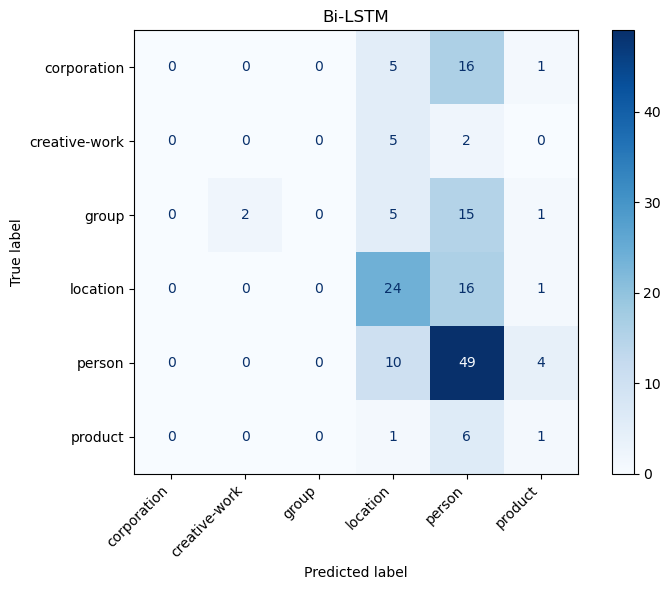

In [38]:
plot_ner_confusion_matrix(y_true_tags, y_pred_tags, "Bi-LSTM")


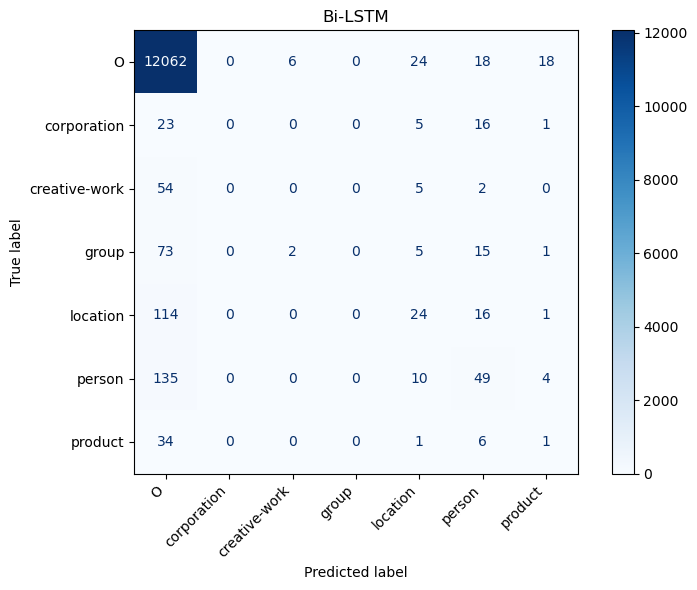

In [39]:
plot_ner_confusion_matrix(y_true_tags, y_pred_tags, "Bi-LSTM",exclude_O=False)

---
## Part 3b: Bi-LSTM + CRF

The Bi-LSTM alone makes **independent** predictions for each token.
Adding a CRF layer on top enforces **sequence consistency** — it learns
that B-PER should be followed by I-PER (not I-ORG), and that I-LOC
shouldn't appear without a preceding B-LOC.

**Architecture:**
```
Input → Embedding → Bi-LSTM → (emission scores per token)
                                      ↓
                               CRF Layer → (best label sequence)
```

**Approach:** We use the Bi-LSTM's softmax outputs as features for
a CRF model trained with `pycrfsuite`. This is a two-stage approach:
1. Bi-LSTM produces per-token probability distributions (emission scores)
2. CRF uses those distributions + transition patterns to find the optimal label sequence

This avoids the complexity of end-to-end Bi-LSTM-CRF training in TensorFlow
while still capturing the benefit of sequence-level consistency.

In [40]:
# ============================================================
# Bi-LSTM + CRF: Use Bi-LSTM emissions as CRF features
# ============================================================
# We take the trained Bi-LSTM model from Part 3 and use its
# softmax output probabilities as input features for a CRF.
#
# Why this works:
# - Bi-LSTM captures contextual patterns (word embeddings + left/right context)
# - CRF captures transition patterns (which label sequences are valid)
# - Together they outperform either model alone

!pip install python-crfsuite

import pycrfsuite

# --- Step 1: Extract Bi-LSTM emission features ---
# Get the model's softmax predictions for each token in train and test sets
# These probability distributions become the CRF's input features

def extract_bilstm_features(model, X_data, idx2tag):
    """
    Run the Bi-LSTM model and convert its softmax outputs to CRF features.

    For each token, we create a feature dict where:
    - Each key is a tag name (e.g., "emit_B-PER")
    - Each value is the Bi-LSTM's predicted probability for that tag
    - This gives the CRF rich per-token information from the neural model

    Args:
        model: trained Bi-LSTM Keras model
        X_data: padded input sequences (word IDs)
        idx2tag: dict mapping tag indices to tag names

    Returns:
        List of sentences, where each sentence is a list of feature dicts
    """
    # Get softmax probabilities for all tokens
    # Shape: (num_sentences, max_len, num_tags)
    probs = model.predict(X_data, verbose=0)

    all_features = []
    for sent_idx in range(len(X_data)):
        sent_features = []
        for tok_idx in range(len(X_data[sent_idx])):
            # Skip padding tokens (word ID = 0)
            if X_data[sent_idx][tok_idx] == 0:
                continue

            # Create feature dict from Bi-LSTM probabilities
            # Each tag's probability becomes a feature
            feat = {}
            for tag_idx, tag_name in idx2tag.items():
                feat[f"emit_{tag_name}"] = float(probs[sent_idx][tok_idx][tag_idx])

            # Add the argmax prediction as a categorical feature
            best_tag = idx2tag[int(np.argmax(probs[sent_idx][tok_idx]))]
            feat["bilstm_pred"] = best_tag

            # Add confidence feature (max probability)
            feat["confidence"] = float(np.max(probs[sent_idx][tok_idx]))

            sent_features.append(feat)
        all_features.append(sent_features)

    return all_features

# Extract features from train and test sets
print("Extracting Bi-LSTM emission features...")
X_train_crf = extract_bilstm_features(model, X_train_nn, idx2tag)
X_test_crf = extract_bilstm_features(model, X_test_nn, idx2tag)

print(f"Train: {len(X_train_crf)} sentences")
print(f"Test:  {len(X_test_crf)} sentences")
print(f"Features per token: {len(X_train_crf[0][0])} (one per tag + pred + confidence)")
print(f"\nExample features for first token:")
for k, v in list(X_train_crf[0][0].items())[:5]:
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Extracting Bi-LSTM emission features...
Train: 2715 sentences
Test:  679 sentences
Features per token: 15 (one per tag + pred + confidence)

Example features for first token:
  emit_B-corporation: 0.0006
  emit_B-creative-work: 0.0021
  emit_B-group: 0.0030
  emit_B-location: 0.0011
  emit_B-person: 0.0009


In [41]:
# --- Step 2: Extract gold labels (same order as features) ---
# We need labels that match the feature sequences (excluding padding)

def extract_gold_labels(X_data, y_data_onehot, idx2tag):
    """
    Extract gold labels aligned with non-padding tokens.

    Args:
        X_data: padded input sequences (to identify padding positions)
        y_data_onehot: one-hot encoded gold labels
        idx2tag: dict mapping tag indices to tag names

    Returns:
        List of sentences, where each sentence is a list of tag strings
    """
    all_labels = []
    y_ids = np.argmax(y_data_onehot, axis=-1)  # one-hot → class IDs

    for sent_idx in range(len(X_data)):
        sent_labels = []
        for tok_idx in range(len(X_data[sent_idx])):
            if X_data[sent_idx][tok_idx] == 0:
                continue  # skip padding
            sent_labels.append(idx2tag[y_ids[sent_idx][tok_idx]])
        all_labels.append(sent_labels)

    return all_labels

y_train_crf = extract_gold_labels(X_train_nn, y_train_nn, idx2tag)
y_test_crf = extract_gold_labels(X_test_nn, y_test_nn, idx2tag)

# Verify alignment: features and labels must have same lengths
assert all(len(f) == len(l) for f, l in zip(X_train_crf, y_train_crf)), "Misaligned train!"
assert all(len(f) == len(l) for f, l in zip(X_test_crf, y_test_crf)), "Misaligned test!"
print(f"Alignment verified!")
print(f"  Train: {sum(len(s) for s in y_train_crf)} tokens across {len(y_train_crf)} sentences")
print(f"  Test:  {sum(len(s) for s in y_test_crf)} tokens across {len(y_test_crf)} sentences")

Alignment verified!
  Train: 50005 tokens across 2715 sentences
  Test:  12725 tokens across 679 sentences


In [42]:
# --- Step 3: Train CRF on Bi-LSTM features ---
# pycrfsuite is a fast C++ implementation of CRF

trainer_crf = pycrfsuite.Trainer(verbose=True)

# Add training data
for features, labels in zip(X_train_crf, y_train_crf):
    trainer_crf.append(features, labels)

# Set training parameters
trainer_crf.set_params({
    'c1': 0.1,                # L1 regularization
    'c2': 0.1,                # L2 regularization
    'max_iterations': 100,
    'feature.possible_transitions': True,  # learn ALL transition patterns
})

print("Training CRF on Bi-LSTM emission features...")
trainer_crf.train('bilstm_crf.model')
print("Bi-LSTM + CRF model saved to: bilstm_crf.model")

Training CRF on Bi-LSTM emission features...
Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 428
Seconds required: 0.016

L-BFGS optimization
c1: 0.100000
c2: 0.100000
num_memories: 6
max_iterations: 100
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

***** Iteration #1 *****
Loss: 47610.041257
Feature norm: 1.000000
Error norm: 65223.330312
Active features: 425
Line search trials: 1
Line search step: 0.000011
Seconds required for this iteration: 0.095

***** Iteration #2 *****
Loss: 13898.881742
Feature norm: 3.961746
Error norm: 4175.218842
Active features: 414
Line search trials: 1
Line search step: 1.000000
Seconds required for this iteration: 0.051

***** Iteration #3 *****
Loss: 13101.001564
Feature norm: 3.810437
Error norm: 4049.980724
Active features: 381
Line search trials: 1
Line search 

In [43]:
# --- Step 4: Evaluate Bi-LSTM + CRF ---
# Compare: Bi-LSTM alone vs Bi-LSTM + CRF

# Load the trained CRF model
tagger = pycrfsuite.Tagger()
tagger.open('bilstm_crf.model')

# Predict with Bi-LSTM + CRF
y_pred_bilstm_crf = [tagger.tag(features) for features in X_test_crf]

# We already have Bi-LSTM-only predictions from Part 3 (y_pred_tags)
# Let's compare both

print("=" * 60)
print("Bi-LSTM ONLY — Entity-Level Evaluation:")
print("=" * 60)
print(seq_report(y_true_tags, y_pred_tags))

print()
print("=" * 60)
print("Bi-LSTM + CRF — Entity-Level Evaluation:")
print("=" * 60)
print(seq_report(y_test_crf, y_pred_bilstm_crf))

# Direct F1 comparison
from seqeval.metrics import f1_score as seq_f1
f1_bilstm = seq_f1(y_true_tags, y_pred_tags)
f1_bilstm_crf = seq_f1(y_test_crf, y_pred_bilstm_crf)

print(f"\nF1 Comparison:")
print(f"  Bi-LSTM only:    {f1_bilstm:.4f}")
print(f"  Bi-LSTM + CRF:   {f1_bilstm_crf:.4f}")
diff = f1_bilstm_crf - f1_bilstm
sign = "+" if diff >= 0 else ""
print(f"  Difference:      {sign}{diff:.4f}")

if f1_bilstm_crf > f1_bilstm:
    print("\n→ CRF layer improved performance by enforcing sequence consistency!")
elif f1_bilstm_crf == f1_bilstm:
    print("\n→ Same F1 — CRF didn't help (Bi-LSTM predictions were already consistent)")
else:
    print("\n→ CRF didn't help here (can happen with small data or already-consistent predictions)")

Bi-LSTM ONLY — Entity-Level Evaluation:
               precision    recall  f1-score   support

  corporation       0.00      0.00      0.00        39
creative-work       0.00      0.00      0.00        30
        group       0.00      0.00      0.00        62
     location       0.23      0.13      0.16       117
       person       0.23      0.18      0.20       136
      product       0.00      0.00      0.00        20

    micro avg       0.20      0.10      0.13       404
    macro avg       0.08      0.05      0.06       404
 weighted avg       0.14      0.10      0.11       404


Bi-LSTM + CRF — Entity-Level Evaluation:
               precision    recall  f1-score   support

  corporation       0.55      0.15      0.24        39
creative-work       0.00      0.00      0.00        30
        group       0.00      0.00      0.00        62
     location       0.31      0.15      0.21       117
       person       0.27      0.21      0.24       136
      product       0.00      0.00

c:\Users\avo9\AppData\Local\anaconda3\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


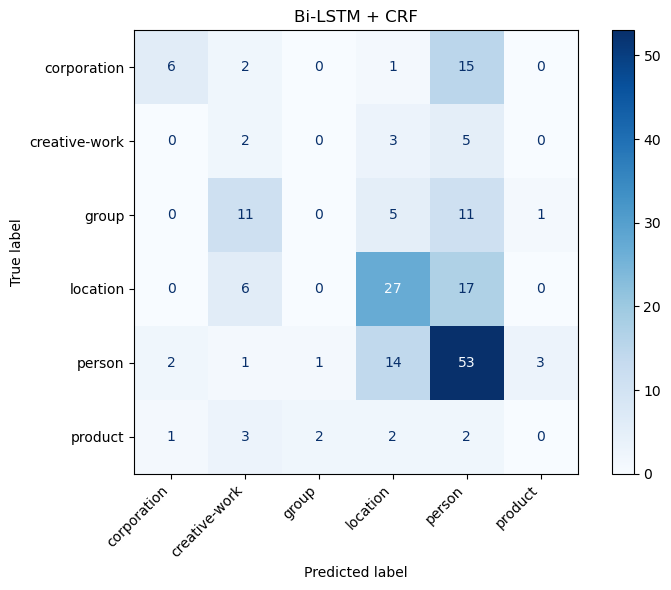

In [44]:
plot_ner_confusion_matrix(y_test_crf, y_pred_bilstm_crf, "Bi-LSTM + CRF")


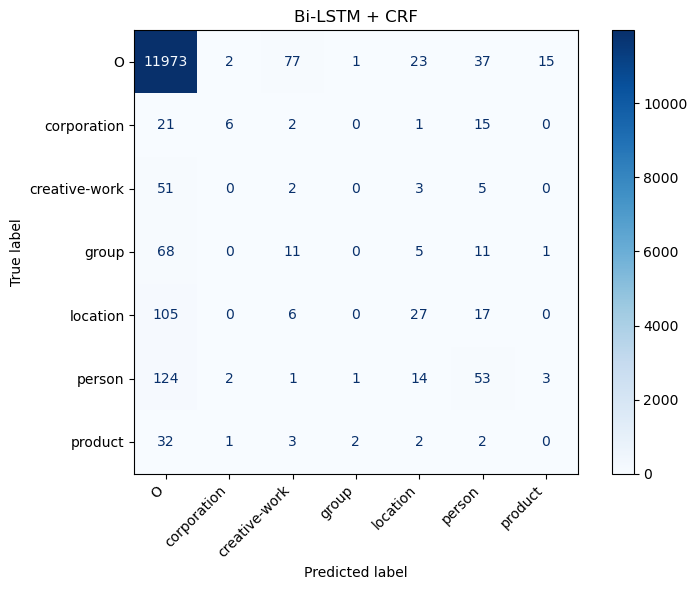

In [45]:
plot_ner_confusion_matrix(y_test_crf, y_pred_bilstm_crf, "Bi-LSTM + CRF",exclude_O=False)


In [46]:
# --- Step 5: Inspect where CRF fixed Bi-LSTM errors ---
# Look at specific sentences where the two models disagree

print("SENTENCES WHERE Bi-LSTM + CRF DIFFERS FROM Bi-LSTM ALONE:")
print("=" * 60)

diff_count = 0
for i, (feats, gold, pred_crf) in enumerate(zip(X_test_crf, y_test_crf, y_pred_bilstm_crf)):
    # Get Bi-LSTM-only predictions for this sentence
    # (reconstruct from the bilstm_pred feature we stored)
    pred_bilstm = [f["bilstm_pred"] for f in feats]

    if pred_bilstm != pred_crf and diff_count < 5:
        diff_count += 1
        print(f"\nSentence {i}:")
        print(f"  {'Token':<20} {'Gold':<12} {'Bi-LSTM':<12} {'+ CRF':<12} {'CRF fixed?'}")
        print(f"  {'-'*68}")

        # Recover original tokens from test data
        # (we need to match by index since we don't have them directly)
        for j in range(len(gold)):
            g, b, c = gold[j], pred_bilstm[j], pred_crf[j]
            if b != c:
                fixed = "✓ FIXED" if c == g else "✗ WORSE" if b == g else "~ DIFF"
                print(f"  {'[token]':<20} {g:<12} {b:<12} {c:<12} {fixed}")

if diff_count == 0:
    print("  No differences found — both models produced identical predictions.")
    print("  This can happen when the Bi-LSTM is already highly confident.")

SENTENCES WHERE Bi-LSTM + CRF DIFFERS FROM Bi-LSTM ALONE:

Sentence 14:
  Token                Gold         Bi-LSTM      + CRF        CRF fixed?
  --------------------------------------------------------------------
  [token]              B-person     B-location   B-corporation ~ DIFF

Sentence 21:
  Token                Gold         Bi-LSTM      + CRF        CRF fixed?
  --------------------------------------------------------------------
  [token]              O            O            B-person     ✗ WORSE

Sentence 42:
  Token                Gold         Bi-LSTM      + CRF        CRF fixed?
  --------------------------------------------------------------------
  [token]              B-product    I-product    B-group      ~ DIFF
  [token]              I-product    B-person     I-group      ~ DIFF

Sentence 43:
  Token                Gold         Bi-LSTM      + CRF        CRF fixed?
  --------------------------------------------------------------------
  [token]              B-group  

---
## Part 4: Model Comparison

| Approach | Features | Data Needed | Strengths | Weaknesses |
|----------|----------|-------------|-----------|------------|
| **CRF** | Hand-crafted | Small (100+) | Fast, interpretable | Can't handle OOV |
| **Bi-LSTM** | Learned embeddings | Medium (500+) | No feature engineering | No sequence constraints |
| **Bi-LSTM + CRF** | Learned + transitions | Medium (500+) | Best of both worlds | More complex pipeline |
| **Transformer** | Pretrained + fine-tuned | Medium (200+) | Best accuracy | Needs GPU, slower |

### Which Should You Use?
- **CRF**: When you have small data and need fast iteration
- **Bi-LSTM**: Rarely used alone today (add CRF or use Transformers)
- **Bi-LSTM + CRF**: Good when you need sequence consistency without GPU
- **Transformer**: Default choice for new NER projects → see **Notebook 2b**
